# 01 – Explore MIT-BIH Dataset
Use this notebook to inspect raw signals, annotations, and label distributions.

### Loading the raw data from it

In [ ]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np


In [60]:
def _default_data_root() -> Path:
    """Search for data/mitbih robustly."""
    candidates: list[Path] = []

    # If running in scripts
    try:
        candidates.append(Path(__file__).resolve().parents[2])
    except NameError:
        # __file__ is undefined in Jupyter, so start from cwd() instead
        candidates.append(Path.cwd().resolve())

    # Add parent dirs of cwd (for notebooks)
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)

    # Try all candidates
    for base in candidates:
        candidate = base / "data" / "mitbih"
        if candidate.exists():
            return candidate

    # Final fallback
    return cwd / "data" / "mitbih"


Wfdb ... 이걸 왜 쓰냐?

WFDB (WaveForm DataBase Toolkit) 은 MIT Lab for Computational Physiology(= PhysioNet 팀)이 만든
의료 신호 처리 전용 라이브러리

그러다 보니 핵심 기능으로써
ECG/PPG/EEG/ABP 등 다양한 생체신호 데이터 로딩
record.hea 파일 자동 파싱 (Sampling rate, channel, unit 등)
노이즈 세그먼트 자동 감지/annotation 활용 가능
R-peak detection, filtering 등 기본 DSP 함수 제공
PhysioNet의 모든 데이터셋과 100% 호환


MIT-BIH는 WFDB 없으면 제대로 다루기 불편함
데이터가 .dat, .hea, .atr 등으로 나뉘는데 이를 파싱하는 건 매우 번거롭다.
WFDB는 이걸 한 줄 리딩으로 해결한다.
이상치 탐지 연구에 최적화된 구조
MIT-BIH는 annotation(이상 박동 종류)이 매우 풍부하다.
WFDB는 annotations = wfdb.rdann(...) 로 바로 불러온다.
→ Ground truth 만들 때 필수.
논문 reproducibility(재현성)에 필수
학계에서 PhysioNet 기반 연구는 다 WFDB로 처리한다.
즉 네 연구는 리뷰어 평가에서 안정적으로 보인다.
신호 처리 기본기 + 실험 설계가 쉬워진다
필터링, 리샘플링, QRS 탐지 등 직접 코드 짜면 2주 걸릴 것들을
WFDB로는 2시간 안에 끝낸다.


다른 방안들은 ?
| 방법                      | 장점             | 치명적 단점                               |
| ----------------------- | -------------- | ------------------------------------ |
| **SciPy + NumPy 직접 파싱** | 가벼움            | MIT-BIH 형식 직접 파싱해야 함, annotation 못 씀 |
| **BioSPPy**             | ECG 전처리 자동화    | MIT-BIH 완전 호환 아님, annotation 기능 약함   |
| **PyWavelets**          | 웨이블릿 기반 이상치 탐지 | 데이터 파싱 기능 없음                         |
| **MNE (EEG용)**          | 시각화/전처리 강함     | ECG 중심 연구엔 불필요하게 무거움                 |


### Why WFDB?

MIT-BIH Arrhythmia Database uses a specialized format (.dat, .hea, .atr) that
contains encoded waveform data and associated annotations. Manually parsing
these files is time-consuming and error-prone.

WFDB is the official PhysioNet-supported toolkit that provides:

- Reliable loading of ECG signals and annotations
- Consistent sampling rate/metadata parsing
- Built-in ECG processing utilities (filtering, R-peak detection, etc.)
- Reproducible preprocessing pipelines widely used in academic research

For these reasons, WFDB is chosen as the primary data-loading backend for this project.


In [7]:
%pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.3 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


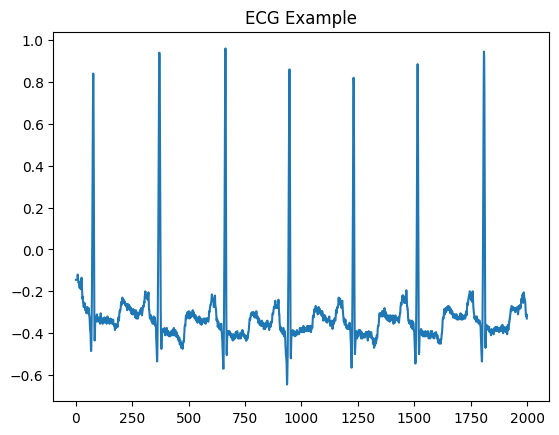

In [61]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb')
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:, 0]

plt.plot(signal[:2000])
plt.title("ECG Example")
plt.show()


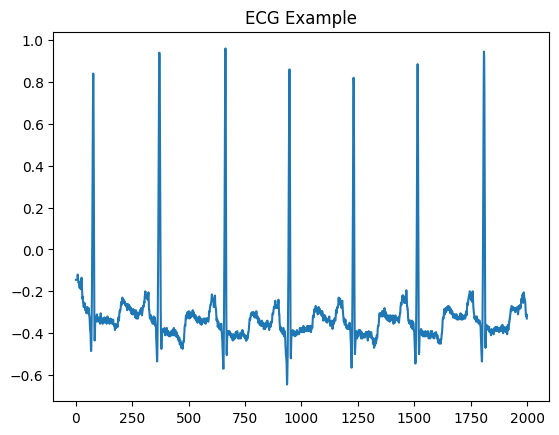

In [62]:
## Data Loading from data/mitbih
## with WFDB
from pathlib import Path
import matplotlib.pyplot as plt
import wfdb
data_root = Path("/Users/daeyeop/Desktop/EKG-Playground/data/mitbih")
## 100번 레코드 로드
record = wfdb.rdrecord(str(data_root / "100"))
## 100번 레코드의 atr 애널라이즈 로드
ann = wfdb.rdann(str(data_root / "100"), "atr")

signal = record.p_signal[:, 0]

plt.plot(signal[:2000])
plt.title("ECG Example")
plt.show()

Parameter Notes (add a table/markdown cell):

record_id: "100", "101", etc. – choose patient/record.
channel_names: select ["MLII", "V5"] or default all channels.
sampfrom, sampto: limit region to speed up plotting.
SegmentationConfig.pre_window/post_window: controls how many seconds before/after R-peak are included (defaults 0.2s and 0.4s).
fs: sampling frequency (360 Hz) for both loader and segmentation.

Key rdrecord parameters worth documenting while you build the loader:
record_name: base filename (e.g., "100" or absolute path).
sampfrom/sampto: integer sample indices for slicing; default loads the full 30‑minute signal.
physical (True/False): return physical units (p_signal) vs raw ADC (d_signal).
channel_names: list like ["MLII", "V5"] to select specific leads; None loads all.
pn_dir: remote PhysioNet directory; leave unset when reading local files.
rdann(record_name, extension="atr", ...) options:

extension: annotation type ("atr" for beat labels, "qrs" etc. for others).
sampfrom/sampto: limit annotation window.
pn_dir: same as above; only needed for remote fetches.
return_label_elements: set True to also retrieve structured label fields.

레코드 로드와 에널라이즈 로드
레코드 로드는 원본 파형(.dat/.hea)를 읽어들여 시계열 신호를 메모리에 올리는 작업
위의 wfdb.rdrecode()를 감싸며, 아웃풋은  signal (num_sampe, num_channels) 형태의 파형이며 meta에도 체널/샘플링 정보가 들어감

에널라이즈(annotaion) 로드 는 같은 레코드에 대응되는 이벤트 라펠 (.atr등)을 불러오는 절차.
코드에서 같은 파일에서 wfdb.rdann(..., "atr")를 호출해 meta["sample"](각 이벤트의 샘플 인덱스)와 meta["symbol"](N, V, etc. 같은 AAMI 심볼)을 가져옵니다. 즉, rdrecord가 “신호”를, rdann이 “라벨”을 담당.

결론은 
Record load → 파형/메타데이터 (채널, 샘플링레이트, raw signal).
Annotation load → 비트 타입, PVC/PAC 등 이벤트 심볼과 발생 시점.

Beat-level 데이터셋 구성: 모델 입력은 segment_beats()가 만들어낸 (num_beats, window_samples) 배열이고, 라벨은 meta["symbol"][keep_idx]가 되어야 함—그래야 CNN/AE가 한 비트 단위로 학습/평가 가능.
정확한 라벨 보존: 슬라이싱 과정에서 신호 시작/끝 때문에 버려지는 비트가 생기므로, keep_idx로 남은 라벨만 골라 매치하지 않으면 비트와 라벨이 어긋나 버림.
특징 추출 연계: src/detection/feature_engineering.py (line 27) 같은 hand-crafted 피처나 AE reconstruction error를 계산할 때도 각 세그먼트가 정확히 어느 이벤트인지 알아야 임상적으로 의미 있는 분석/threshold 설정이 가능.

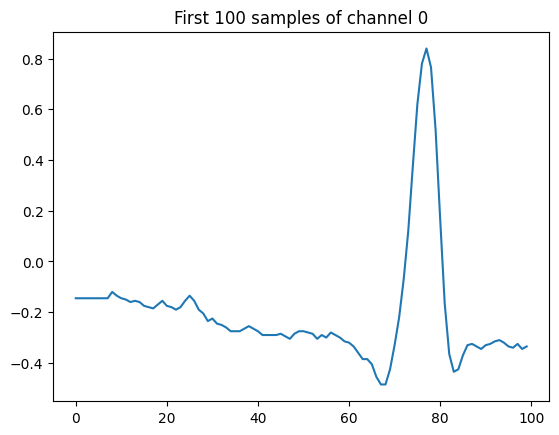

In [63]:
import pandas as pd
## 데이터를 알아보기
record =  wfdb.rdrecord(str(data_root / "100"))
## 데이터 프레임 형태로 변환
df = pd.DataFrame(record.p_signal, columns=record.sig_name)
## 첫 번째 채널의 처음 100개 샘플 표시
df.iloc[:100, 0].plot()
plt.title("First 100 samples of channel 0")
plt.show()

MLII 리드는 360Hz로 샘플링했고, raw 값에서 1024를 빼고 200으로 나누면 mV가 나오며, ADC는 11비트 해상도...


시간 기반 지표 (fs 활용)

RR 간격 변동, 심박수, PR/QT/QTc 간격, QRS 폭, PVC/APB 커플링 간격, ST 분절 지연, T-wave alternans 윈도우 등을 초 단위로 계산할 수 있음. 샘플 인덱스를 시간 = 샘플 / fs (360Hz)로 환산해 측정하므로, fs를 아는 것이 필수. 예: R-peak 간 샘플 차이가 180이면 180 / 360 = 0.5초, 즉 120bpm.
전압/형태 지표 (gain, baseline, units)

ST 상승/하강, R/Q/T 파 진폭, QRS 전압 기준 (Sokolow-Lyon, Cornell), P파 높이, T파 역전 정도, PVC/Q-wave 깊이, 타인 엣지/노치 등. raw 값에서 baseline(1024)을 빼고 gain(200)을 나눠 mV 단위로 변환 → 임상 기준(예: ST 상승 0.1 mV 이상)과 직접 비교 가능.
전압 스케일을 알고 있어야 모델 입력을 정규화할 때도 실제 전압 범위를 유지하며 처리 가능.
리드 별 해석 (channel)

각 리드가 보는 심장 부위가 다르므로 MLII 변화는 하벽, V5 변화는 측벽/좌심실 정보를 의미. PVC 기원 추정, 축 편위, 좌/우각차단 여부 판단 시 다중 리드 비교 필요.
잘못된 리드 연결, 잡음 구간 식별에도 채널 정보가 필수.
신호 품질/처리 기준 (adc_res)

11bit 해상도 → 최대≈2048 단계. 양자화 잡음 수준, 포화 여부, 필터 설계(Nyquist=180 Hz) 판단. 노치/밴드패스 필터 파라미터를 fs와 함께 설정해 노이즈 제거.
진단·해석 흐름 예시

R-peak 탐지 후 RR 간격 = diff(samples) / 360 → HRV 혹은 PVC 커플링 간격 계산.
세그먼트에서 QRS 폭 = (QRS 끝 - Q 시작) 샘플 수 / 360 → 120 ms 초과면 wide QRS, VT 가능성.
ST 분절에서 샘플 29 (~80 ms) 뒤 전압을 ((raw-baseline)/gain)로 변환 → 0.2 mV 상승이면 STEMI 의심.
MLII vs V5 진폭 비교로 R/S 비율, 리드별 ST 패턴을 보고 병변 위치 추론.
adc_res로 포화 구간을 제외하거나 필터 설계(0.5–40 Hz)시 안전하게 차단 주파수 결정

PVC(조기 심실수축) 의심

fs=360Hz 덕분에 RR 간격을 diff(R-peak samples) / 360으로 정확히 계산합니다.
어떤 RR이 바로 앞 RR보다 훨씬 짧게(예: 0.5초 미만) 나타나고, 그 다음 RR이 길게 나타나면 “조기-보상” 패턴 → PVC를 의심할 수 있습니다.
같은 beat의 QRS 폭을 계산: 폭 = (QRS_end - QRS_start)/360. 120ms 이상이면 wide QRS → PVC 가능성이 커짐.
gain/baseline으로 전압을 mV 단위로 환산해, 해당 beat의 QRS 진폭이 정상 beat보다 커지거나 ST/T 모양이 다르게 나타나는 것을 확인합니다.
channel 정보를 보면서 MLII, V5 모두에서 모양이 바뀌었는지, 특정 리드에서만 이상한지 확인해 초점 위치를 추정합니다.
ST Elevation MI (심근경색) 의심

R-peak 이후 80ms 지점(샘플 29)에서 측정한 전압을 ((raw - baseline)/gain)으로 mV로 바꿉니다.
MLII와 V5 각각에서 ST가 0.1 mV 이상 상승하고, 리드 위치에 따라 하벽/측벽 병변을 더 추정합니다.
시간적 지속성(몇 초 이상 지속)과 동반 T파 변화까지 확인해 진단 근거를 쌓습니다.

부정맥 패턴: RR 간격 기반으로 PVC, APB, 비정상 서맥/빈맥, AF (불규칙 RR) 등을 구분.
전도장애: PR 연장(1도 AV block), QRS 폭 증가(각차단, VT), QT 연장 등 시간 지표들.
허혈/심근경색: ST 상승/하강, T파 역전, Q-wave 형성. 리드별로 위치 추론 가능.
심실/심방 비대: QRS/R파 진폭 규칙, P파 높이 등을 mV 단위로 계산해 Sokolow-Lyon, Cornell 기준 같은 스코어 적용.
전극 이상/노이즈 확인: 특정 리드만 flat-line 이거나 baseline shift가 크면 리드 접촉 문제 추정.
HRV 분석: RR 시계열로 LF/HF, RMSSD 등 계산해 자율신경 톤 평가.
T-wave alternans, signal quality: 고해상도 샘플링/전압 스케일이 있어야 미세한 변화나 artefact를 감지 가능.

In [64]:
import pandas as pd
## 데이터를 알아보기
record =  wfdb.rdrecord(str(data_root / "100"))
param_table = pd.DataFrame({
    "channel": record.sig_name,
    "fs": record.fs,
    "gain": record.adc_gain,
    "baseline": record.baseline,
    "units": record.units,
    "adc_res": record.adc_res,
})
display(param_table)
print(f"Length (samples): {record.sig_len}, Duration (s): {record.sig_len / record.fs:.1f}")

,channel,fs,gain,baseline,units,adc_res
0,MLII,360,200.0,1024,mV,11
1,V5,360,200.0,1024,mV,11


Length (samples): 650000, Duration (s): 1805.6


위의 테이블 설명 
channel: 리드 이름. MIT-BIH에서는 주로 MLII(Modified Lead II)와 V5를 제공합니다.
fs: 해당 채널의 샘플링 주파수(Hz).
여기서는 360 Hz로 두 채널 모두 동일합니다.
gain: ADC 한 카운트당 물리 단위 변환 계수. 
200 µV/LSB라는 뜻으로, 원시 디지털 값에 gain을 나누고 baseline을 빼면 실제 mV 단위가 됩니다.
baseline: ADC 오프셋. 1024가 기준값이라서, raw 값에서 1024를 빼고 gain으로 스케일링해 물리 신호를 복원합니다.
units: 신호 단위. mV(밀리볼트)로 표준 ECG 전압 단위입니다.
adc_res: ADC 해상도(비트). 11비트(0–2047)로 양자화되어 있다는 뜻입니다.

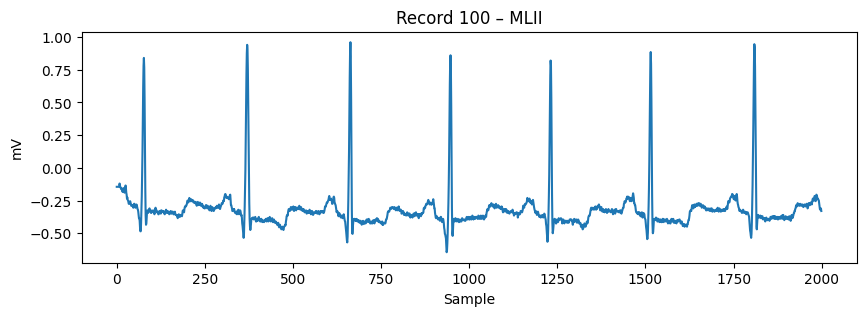

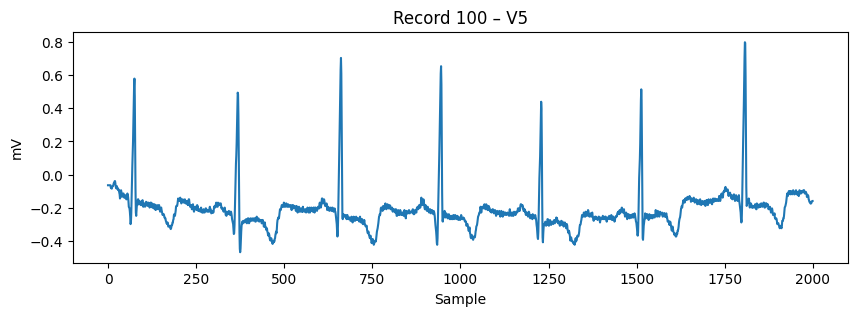

In [65]:
import matplotlib.pyplot as plt

for ch_idx, ch_name in enumerate(record.sig_name):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(record.p_signal[:2000, ch_idx])
    ax.set_title(f"Record 100 – {ch_name}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("mV")
    plt.show()


In [66]:
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
from scipy.signal import find_peaks
@dataclass
class SegmentationConfig:
    fs: float = 360.0
    pre_window: float = 0.2   # seconds before R-peak
    post_window: float = 0.4  # seconds after R-peak
    
def detect_r_peaks(signal: np.ndarray, fs: float = 360.0) -> np.ndarray:
    sig = signal if signal.ndim == 1 else signal[:, 0]
    peaks, _ = find_peaks(sig, distance=int(0.2 * fs))
    return peaks


def segment_beats(signal: np.ndarray, r_peaks: np.ndarray, config: SegmentationConfig | None = None):
    config = config or SegmentationConfig()
    pre = int(config.pre_window * config.fs)
    post = int(config.post_window * config.fs)
    window = pre + post

    if signal.ndim == 1:
        signal = signal[:, None]  # (N,) -> (N, 1)

    beats = []
    keep_idx = []
    for idx, peak in enumerate(r_peaks):
        start = peak - pre
        stop = peak + post
        if start < 0 or stop > signal.shape[0]:
            continue
        beats.append(signal[start:stop, 0])
        keep_idx.append(idx)

    segments = np.stack(beats, axis=0) if beats else np.empty((0, window))
    meta = {
        "r_peaks": np.asarray(r_peaks[keep_idx], dtype=np.int32),
        "window": np.asarray([pre, post], dtype=np.int32),
    }
    return segments, meta



In [67]:
config = SegmentationConfig(pre_window=0.2, post_window=0.4)
peaks = detect_r_peaks(signal)
segments, seg_meta = segment_beats(signal, peaks, config)



In [68]:

# signal, meta는 load_record(...)로 불러온 결과라고 가정
config = SegmentationConfig(pre_window=0.2, post_window=0.4)  # 기본값
segments, seg_meta = segment_beats(signal, peaks, config)

print(segments.shape)         # (num_beats, window_samples)
print(seg_meta["r_peaks"][:5])


(6619, 216)
[ 77 206 298 370 446]


In [71]:
def _require_wfdb() -> None:
    if wfdb is None:
        raise ImportError(
            "wfdb is required to read MIT-BIH records. Install it via pip install wfdb"
        )

def load_record(
    record_id: str,
    *,
    data_root: Path = _default_data_root(),
    channels: Optional[Iterable[str]] = None,
    physical: bool = True,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """Load a full-length record along with annotations."""
    _require_wfdb()
    record_path = str(data_root / record_id)
    record = wfdb.rdrecord(record_path, channel_names=channels, physical=physical)
    annotation = wfdb.rdann(record_path, "atr")
    signal = record.p_signal if physical else record.d_signal
    meta: Dict[str, np.ndarray] = {
        "sample": np.asarray(annotation.sample, dtype=np.int32),
        "symbol": np.asarray(annotation.symbol),
        "aux_note": np.asarray(annotation.aux_note),
    }
    return np.asarray(signal, dtype=np.float32), meta



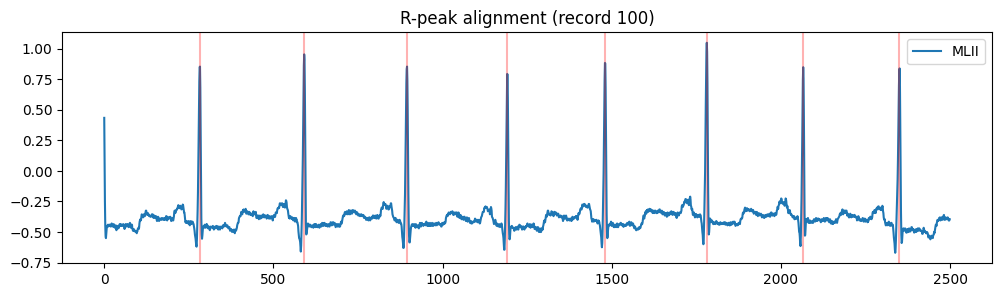

Symbol: N


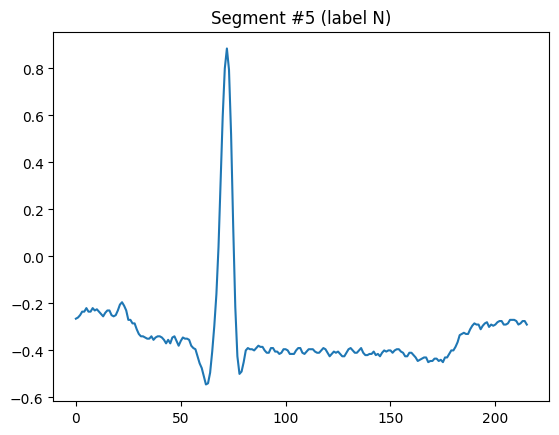

In [72]:

import numpy as np

signal, meta = load_record('100')                           # includes meta["sample"], meta["symbol"]
segments, seg_meta = segment_beats(signal, meta["sample"])  # default 0.2s pre / 0.4s post

# Plot one window with R-peaks marked
window = slice(10000, 12500)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(signal[window, 0], label="MLII")
for peak in meta["sample"]:
    if window.start <= peak <= window.stop:
        ax.axvline(peak - window.start, color="red", alpha=0.3)
ax.legend()
ax.set_title("R-peak alignment (record 100)")
plt.show()

# Inspect a segmented beat and its label
idx = 5
print("Symbol:", meta["symbol"][idx])
plt.plot(segments[idx])
plt.title(f"Segment #{idx} (label {meta['symbol'][idx]})")
plt.show()
